In [ ]:
import os
from google.colab import drive

# 1. Mount Google Drive (if not already mounted)
print("Mounting Google Drive...")
# Note: The drive is already mounted, but it's safe to run this again.
drive.mount('/content/drive', force_remount=True)
print("Drive mounted successfully.")

# 2. Configuration for Paths
# IMPORTANT: Use the exact, un-renamed file names you see on Drive!
PROJECT_FOLDER = '/content/drive/MyDrive/gmlminiproject/'
TRAIN_ZIP_NAME = 'train.csv (1).zip'     # <-- Using the user's messy file name
TEST_ZIP_NAME = 'test_supplement.csv.zip' # <-- Using the user's file name

# 3. Extract Files
os.makedirs(PROJECT_FOLDER, exist_ok=True)

def extract_zip(zip_name, dest_folder):
    zip_path = os.path.join(dest_folder, zip_name)
    if os.path.exists(zip_path):
        print(f"Extracting {zip_name}...")
        # CRITICAL FIX: The shell command must use double quotes around variables to handle spaces/special characters
        !unzip -q "$zip_path" -d "$dest_folder"
        print(f"{zip_name} extracted successfully.")
    else:
        print(f"ERROR: Zip file not found at {zip_path}. Check your file names and location.")

# Run extraction
extract_zip(TRAIN_ZIP_NAME, PROJECT_FOLDER)
extract_zip(TEST_ZIP_NAME, PROJECT_FOLDER)

# 4. Final Path Setup for Section 1
TD_TRAIN_PATH = os.path.join(PROJECT_FOLDER, 'train.csv')
TD_TEST_PATH = os.path.join(PROJECT_FOLDER, 'test_supplement.csv')

print("\nExtraction finished. If no new errors occurred, you can now run the Data Loading (Section 1) script.")

Mounting Google Drive...
Mounted at /content/drive
Drive mounted successfully.
Extracting train.csv (1).zip...
replace /content/drive/MyDrive/gmlminiproject/train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: train.csv (1).zip extracted successfully.
Extracting test_supplement.csv.zip...
replace /content/drive/MyDrive/gmlminiproject/test_supplement.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: test_supplement.csv.zip extracted successfully.

Extraction finished. If no new errors occurred, you can now run the Data Loading (Section 1) script.


In [ ]:

import pandas as pd
import os

# Paths
TRAIN_FILE = '/content/drive/MyDrive/gmlminiproject/train.csv'

# Use nullable integer types to handle any missing values safely
dtypes = {
    'ip': 'Int64',
    'app': 'Int32',
    'device': 'Int32',
    'os': 'Int32',
    'channel': 'Int32',
    'is_attributed': 'Int8'
}

# Number of rows to load
ROWS = 1_000_000

# Load dataset
if os.path.exists(TRAIN_FILE):
    print(f"Loading {ROWS:,} rows from {TRAIN_FILE} ...")
    df = pd.read_csv(
        TRAIN_FILE,
        dtype=dtypes,
        parse_dates=['click_time'],
        usecols=['ip','app','device','os','channel','click_time','is_attributed'],
        nrows=ROWS
    )
else:
    raise FileNotFoundError(f"{TRAIN_FILE} not found. Check your path.")

print("✅ Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()


Loading 1,000,000 rows from /content/drive/MyDrive/gmlminiproject/train.csv ...
✅ Dataset loaded successfully.
Shape: (1000000, 7)


,ip,app,device,os,channel,click_time,is_attributed
0,83230,3,1,13,379,2017-11-06 14:32:21,0
1,17357,3,1,19,379,2017-11-06 14:33:34,0
2,35810,3,1,13,379,2017-11-06 14:34:12,0
3,45745,14,1,13,478,2017-11-06 14:34:52,0
4,161007,3,1,13,379,2017-11-06 14:35:08,0


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 7 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   ip             1000000 non-null  Int64         
 1   app            1000000 non-null  Int32         
 2   device         1000000 non-null  Int32         
 3   os             1000000 non-null  Int32         
 4   channel        1000000 non-null  Int32         
 5   click_time     1000000 non-null  datetime64[ns]
 6   is_attributed  1000000 non-null  Int8          
dtypes: Int32(4), Int64(1), Int8(1), datetime64[ns](1)
memory usage: 37.2 MB
None

Missing values:
 ip               0
app              0
device           0
os               0
channel          0
click_time       0
is_attributed    0
dtype: int64

Unique counts:
ip               39611
app                214
device             298
os                 160
channel            154
click_time        173

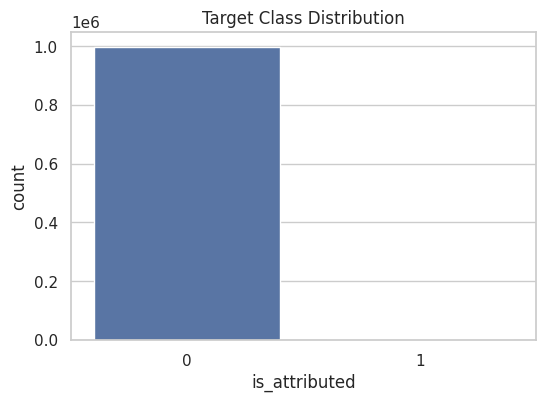

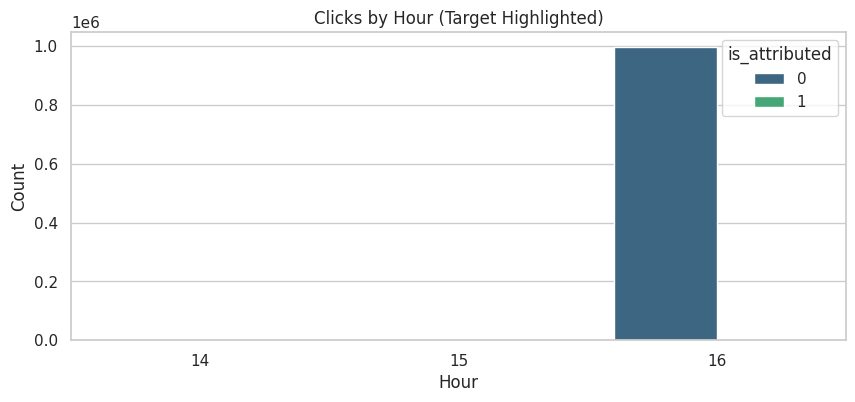

Feature engineering complete. Memory usage (MB): 52.452213287353516


,ip,app,device,os,channel,click_time,is_attributed,hour,day,weekday,is_weekend,clicks_per_ip_hour,unique_apps_per_ip,unique_channels_per_ip,unique_devices_per_ip,anomaly_score
0,83230,3,1,13,379,2017-11-06 14:32:21,0,14,6,0,0,1,19,46,1,0.471087
1,17357,3,1,19,379,2017-11-06 14:33:34,0,14,6,0,0,1,20,42,1,0.468037
2,35810,3,1,13,379,2017-11-06 14:34:12,0,14,6,0,0,1,17,35,3,0.464518
3,45745,14,1,13,478,2017-11-06 14:34:52,0,14,6,0,0,1,31,81,6,0.474711
4,161007,3,1,13,379,2017-11-06 14:35:08,0,14,6,0,0,1,1,1,1,0.504722


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

sns.set(style='whitegrid')

# ----------------------
# 1. Basic Info
# ----------------------
print("Dataset info:")
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nUnique counts:")
print(df.nunique())

# Target distribution
plt.figure(figsize=(6,4))
sns.countplot(x='is_attributed', data=df)
plt.title("Target Class Distribution")
plt.show()

# ----------------------
# 2. Datetime Features
# ----------------------
df['hour'] = df['click_time'].dt.hour.astype('uint8')
df['day'] = df['click_time'].dt.day.astype('uint8')
df['weekday'] = df['click_time'].dt.weekday.astype('uint8')
df['is_weekend'] = (df['weekday'] >= 5).astype('uint8')

# Hourly click trend
plt.figure(figsize=(10,4))
sns.countplot(x='hour', data=df, hue='is_attributed', palette='viridis')
plt.title("Clicks by Hour (Target Highlighted)")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

# ----------------------
# 3. Aggregation Features (Memory-Efficient)
# ----------------------
# Clicks per IP per hour
df['clicks_per_ip_hour'] = df.groupby(['ip','hour'])['click_time'].transform('count').astype('uint16')

# Unique apps per IP
df['unique_apps_per_ip'] = df.groupby('ip')['app'].transform('nunique').astype('uint16')

# Unique channels per IP
df['unique_channels_per_ip'] = df.groupby('ip')['channel'].transform('nunique').astype('uint16')

# Unique devices per IP
df['unique_devices_per_ip'] = df.groupby('ip')['device'].transform('nunique').astype('uint16')

# ----------------------
# 4. Lightweight Anomaly Score (Unsupervised Feature)
# ----------------------
# Fit Isolation Forest on a small 1% sample to save RAM
sample_frac = 0.01
sample_df = df.sample(frac=sample_frac, random_state=42)

iso = IsolationForest(
    n_estimators=50,
    max_samples=0.1,
    contamination=0.001,
    random_state=42,
    n_jobs=-1
)
iso.fit(sample_df[['ip','app','device','os','channel','hour']])

# Batch predict anomaly score for memory efficiency
def batch_anomaly_score(df, model, batch_size=200_000):
    scores = np.zeros(len(df))
    for start in range(0, len(df), batch_size):
        end = min(start + batch_size, len(df))
        batch = df.iloc[start:end][['ip','app','device','os','channel','hour']]
        scores[start:end] = -model.score_samples(batch)  # higher = more anomalous
    return scores

df['anomaly_score'] = batch_anomaly_score(df, iso).astype('float32')

# ----------------------
# 5. Final Memory Check and Sample
# ----------------------
print("Feature engineering complete. Memory usage (MB):", df.memory_usage(deep=True).sum()/1024**2)
df.head()

Scale pos weight: 589.8419497784342
[LightGBM] [Info] Number of positive: 1354, number of negative: 798646
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.091129 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1052
[LightGBM] [Info] Number of data points in the train set: 800000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001692 -> initscore=-6.379855
[LightGBM] [Info] Start training from score -6.379855

✅ Validation AUC: 0.8091
✅ Average Precision (AP): 0.0121


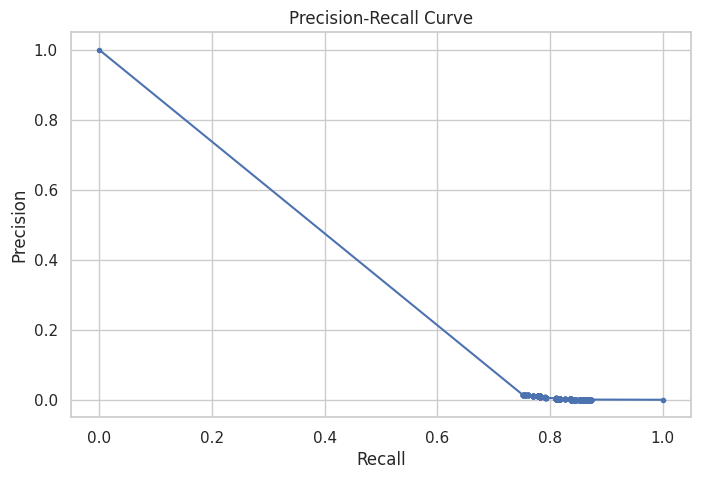

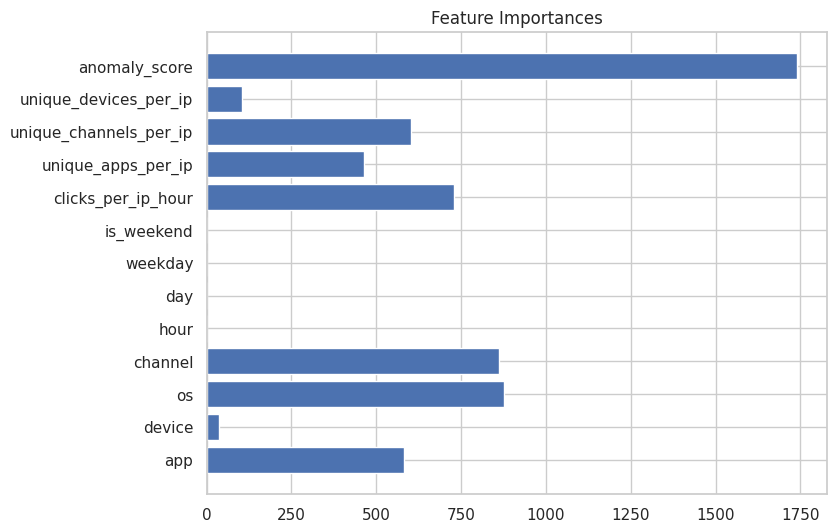

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt

# 1. Define features and target
TARGET = 'is_attributed'
features = [
    'app','device','os','channel','hour','day','weekday','is_weekend',
    'clicks_per_ip_hour','unique_apps_per_ip','unique_channels_per_ip',
    'unique_devices_per_ip','anomaly_score'
]

X = df[features]
y = df[TARGET]

# 2. Train/Test split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Compute scale_pos_weight to handle class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("Scale pos weight:", scale_pos_weight)

# 4. Initialize LGBMClassifier
model = LGBMClassifier(
    objective='binary',
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,
    colsample_bytree=0.8,
    subsample=0.8,
    subsample_freq=1,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

# 5. Fit without early stopping
model.fit(X_train, y_train)

# 6. Predictions and Evaluation
y_pred_prob = model.predict_proba(X_val)[:,1]

auc = roc_auc_score(y_val, y_pred_prob)
ap  = average_precision_score(y_val, y_pred_prob)
print(f"\n✅ Validation AUC: {auc:.4f}")
print(f"✅ Average Precision (AP): {ap:.4f}")

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_val, y_pred_prob)
plt.figure(figsize=(8,5))
plt.plot(recall, precision, marker='.')
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()

# Feature importance
importances = model.feature_importances_
plt.figure(figsize=(8,6))
plt.barh(features, importances)
plt.title("Feature Importances")
plt.show()

[LightGBM] [Info] Number of positive: 1354, number of negative: 13544
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002022 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 942
[LightGBM] [Info] Number of data points in the train set: 14898, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.090885 -> initscore=-2.302880
[LightGBM] [Info] Start training from score -2.302880

✅ Balanced Validation AUC: 0.9335
✅ Balanced Average Precision (AP): 0.8326


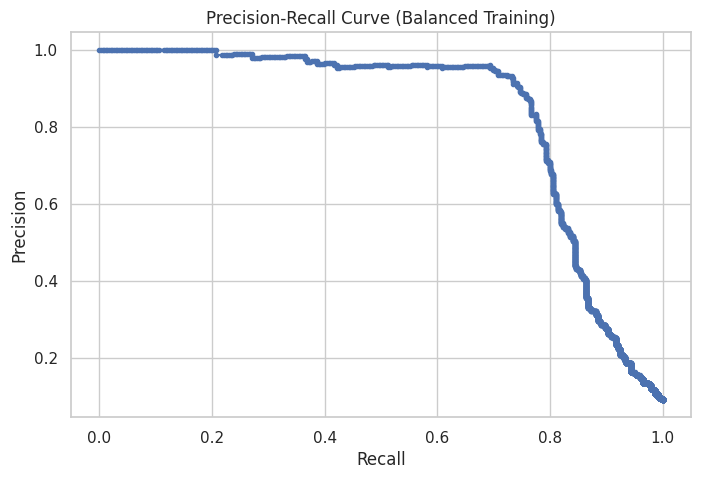

In [ ]:

# ## Layer 2b: Downsampling Majority Class and Retraining

# %%
# 1. Separate fraud and non-fraud
fraud = df[df['is_attributed'] == 1]
non_fraud = df[df['is_attributed'] == 0]

# 2. Downsample non-fraud (e.g., 10x positives)
non_fraud_sampled = non_fraud.sample(n=fraud.shape[0]*10, random_state=42)

# 3. Combine into balanced dataset
df_balanced = pd.concat([fraud, non_fraud_sampled]).sample(frac=1, random_state=42)  # shuffle

X_bal = df_balanced[features]
y_bal = df_balanced[TARGET]

# 4. Train/Test split
X_train_bal, X_val_bal, y_train_bal, y_val_bal = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

# 5. Train LightGBM on balanced set
model_bal = LGBMClassifier(
    objective='binary',
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,
    colsample_bytree=0.8,
    subsample=0.8,
    subsample_freq=1,
    random_state=42,
    n_jobs=-1
)
model_bal.fit(X_train_bal, y_train_bal)

# 6. Predict & Evaluate
y_pred_prob_bal = model_bal.predict_proba(X_val_bal)[:,1]

auc_bal = roc_auc_score(y_val_bal, y_pred_prob_bal)
ap_bal  = average_precision_score(y_val_bal, y_pred_prob_bal)
print(f"\n✅ Balanced Validation AUC: {auc_bal:.4f}")
print(f"✅ Balanced Average Precision (AP): {ap_bal:.4f}")

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_val_bal, y_pred_prob_bal)
plt.figure(figsize=(8,5))
plt.plot(recall, precision, marker='.')
plt.title("Precision-Recall Curve (Balanced Training)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()


In [ ]:
from sklearn.ensemble import IsolationForest
import numpy as np

# 1. Select columns for anomaly detection
iso_features = ['ip','app','device','os','channel','hour','clicks_per_ip_hour']

# 2. Fit Isolation Forest on a small sample (1%) to save RAM
sample_frac = 0.01
iso_sample = df.sample(frac=sample_frac, random_state=42)

iso_model = IsolationForest(
    n_estimators=50,
    max_samples=0.1,
    contamination=0.001,
    random_state=42,
    n_jobs=-1
)
iso_model.fit(iso_sample[iso_features])

# 3. Predict anomaly scores for full dataset in batches
def batch_anomaly_score(df, model, batch_size=200_000):
    scores = np.zeros(len(df))
    for start in range(0, len(df), batch_size):
        end = min(start + batch_size, len(df))
        batch = df.iloc[start:end][iso_features]
        scores[start:end] = -model.score_samples(batch)  # higher = more anomalous
    return scores

df['anomaly_score_unsupervised'] = batch_anomaly_score(df, iso_model).astype('float32')

print("Anomaly feature added successfully. Sample values:")
df[['anomaly_score_unsupervised']].head()

Anomaly feature added successfully. Sample values:


,anomaly_score_unsupervised
0,0.466574
1,0.485687
2,0.468796
3,0.483702
4,0.479265


[LightGBM] [Info] Number of positive: 1354, number of negative: 13544
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023615 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1197
[LightGBM] [Info] Number of data points in the train set: 14898, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.090885 -> initscore=-2.302880
[LightGBM] [Info] Start training from score -2.302880

✅ Final Validation AUC: 0.9361
✅ Final Average Precision (AP): 0.8287


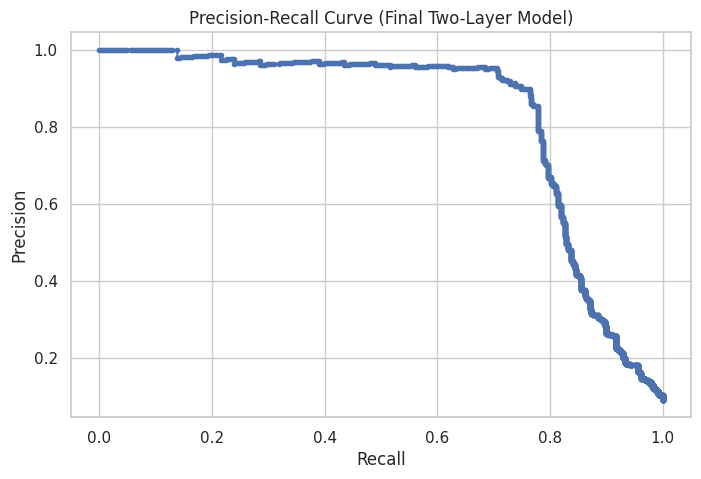

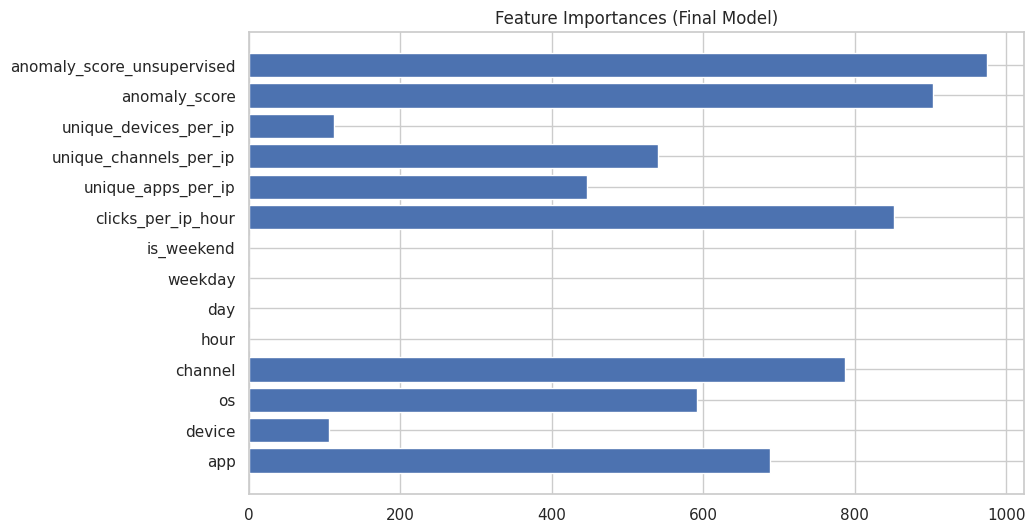

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt

# 1. Add unsupervised anomaly score to features
features_final = features + ['anomaly_score_unsupervised']

# 2. Prepare balanced dataset again
fraud = df[df['is_attributed'] == 1]
non_fraud = df[df['is_attributed'] == 0].sample(n=fraud.shape[0]*10, random_state=42)
df_balanced_final = pd.concat([fraud, non_fraud]).sample(frac=1, random_state=42)

X_bal_final = df_balanced_final[features_final]
y_bal_final = df_balanced_final['is_attributed']

# 3. Train/Test split
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_bal_final, y_bal_final, test_size=0.2, random_state=42, stratify=y_bal_final
)

# 4. Initialize LightGBM
model_final = LGBMClassifier(
    objective='binary',
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,
    colsample_bytree=0.8,
    subsample=0.8,
    subsample_freq=1,
    random_state=42,
    n_jobs=-1
)

# 5. Fit model
model_final.fit(X_train_final, y_train_final)

# 6. Predictions & Evaluation
y_pred_prob_final = model_final.predict_proba(X_val_final)[:,1]

auc_final = roc_auc_score(y_val_final, y_pred_prob_final)
ap_final  = average_precision_score(y_val_final, y_pred_prob_final)
print(f"\n✅ Final Validation AUC: {auc_final:.4f}")
print(f"✅ Final Average Precision (AP): {ap_final:.4f}")

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_val_final, y_pred_prob_final)
plt.figure(figsize=(8,5))
plt.plot(recall, precision, marker='.')
plt.title("Precision-Recall Curve (Final Two-Layer Model)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()

# Feature importance
importances = model_final.feature_importances_
plt.figure(figsize=(10,6))
plt.barh(features_final, importances)
plt.title("Feature Importances (Final Model)")
plt.show()

/tmp/ipython-input-1682532746.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(metrics.keys()), y=[m['AUC'] for m in metrics.values()], palette='coolwarm')


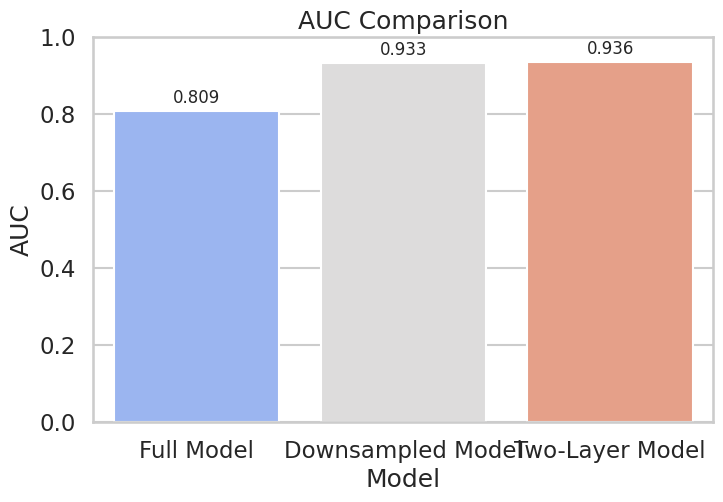

/tmp/ipython-input-1682532746.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(metrics.keys()), y=[m['AP'] for m in metrics.values()], palette='viridis')


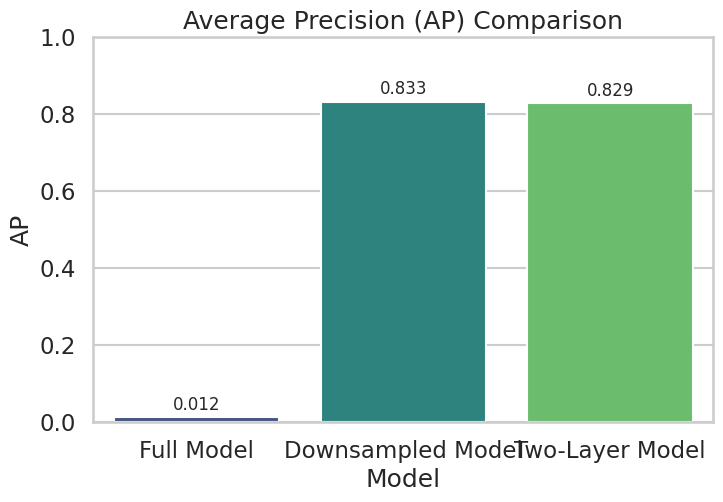

In [ ]:

# ## Performance Comparison: Full vs Downsampled vs Two-Layer Model

# %%
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style='whitegrid', context='talk')

# 1. Define metrics for each model
metrics = {
    'Full Model': {'AUC': 0.8091, 'AP': 0.0121},
    'Downsampled Model': {'AUC': 0.9335, 'AP': 0.8326},
    'Two-Layer Model': {'AUC': 0.9361, 'AP': 0.8287}
}

# 2. Bar plot for AUC
plt.figure(figsize=(8,5))
sns.barplot(x=list(metrics.keys()), y=[m['AUC'] for m in metrics.values()], palette='coolwarm')
plt.ylim(0,1)
plt.title("AUC Comparison")
plt.ylabel("AUC")
plt.xlabel("Model")
for i, val in enumerate([m['AUC'] for m in metrics.values()]):
    plt.text(i, val+0.02, f"{val:.3f}", ha='center', fontsize=12)
plt.show()

# 3. Bar plot for Average Precision (AP)
plt.figure(figsize=(8,5))
sns.barplot(x=list(metrics.keys()), y=[m['AP'] for m in metrics.values()], palette='viridis')
plt.ylim(0,1)
plt.title("Average Precision (AP) Comparison")
plt.ylabel("AP")
plt.xlabel("Model")
for i, val in enumerate([m['AP'] for m in metrics.values()]):
    plt.text(i, val+0.02, f"{val:.3f}", ha='center', fontsize=12)
plt.show()

# 4. Optional: Precision-Recall Curve Comparison
# If you have y_val and y_pred_prob for each model, you can plot them here
# Example using fake data placeholders (replace with your actual predictions if available)
# from sklearn.metrics import precision_recall_curve

# pr_curves = {
#     'Full Model': (precision_full, recall_full),
#     'Downsampled Model': (precision_down, recall_down),
#     'Two-Layer Model': (precision_two, recall_two)
# }

# plt.figure(figsize=(8,6))
# for label, (prec, rec) in pr_curves.items():
#     plt.plot(rec, prec, marker='.', label=label)
# plt.title("Precision-Recall Curve Comparison")
# plt.xlabel("Recall")
# plt.ylabel("Precision")
# plt.grid(True)
# plt.legend()
# plt.show()
